# Gene Comparison - BRCA1, TP53, INS

Comparing three important human genes by GC content,
length, and base composition using NCBI data.

In [1]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
import matplotlib.pyplot as plt

Entrez.email = "rajat@email.com"

In [2]:
genes = {
    "BRCA1": "NM_007294",
    "TP53": "NM_000546",
    "INS": "NM_000207",
}

records = {}
gc_data = {}
lengths = {}

for name, gid in genes.items():
    handle = Entrez.efetch(
        db="nucleotide",
        id=gid,
        rettype="fasta",
        retmode="text"
    )
    record = SeqIO.read(handle, "fasta")
    handle.close()

    records[name] = record
    gc_data[name] = gc_fraction(record.seq) * 100
    lengths[name] = len(record.seq)

    print(f"{name}: {len(record.seq)} bp | GC: {gc_data[name]:.1f}%")

BRCA1: 7088 bp | GC: 41.8%
TP53: 2512 bp | GC: 53.4%
INS: 465 bp | GC: 63.9%


In [3]:
print(f"{'Gene':<10} {'Length':>10} {'GC%':>8}")
print("-" * 30)

for name in genes:
    print(f"{name:<10} {lengths[name]:>8} bp {gc_data[name]:>7.1f}%")

most_stable = max(gc_data, key=gc_data.get)
print(f"\nMost stable: {most_stable} ({gc_data[most_stable]:.1f}%)")

Gene           Length      GC%
------------------------------
BRCA1          7088 bp    41.8%
TP53           2512 bp    53.4%
INS             465 bp    63.9%

Most stable: INS (63.9%)


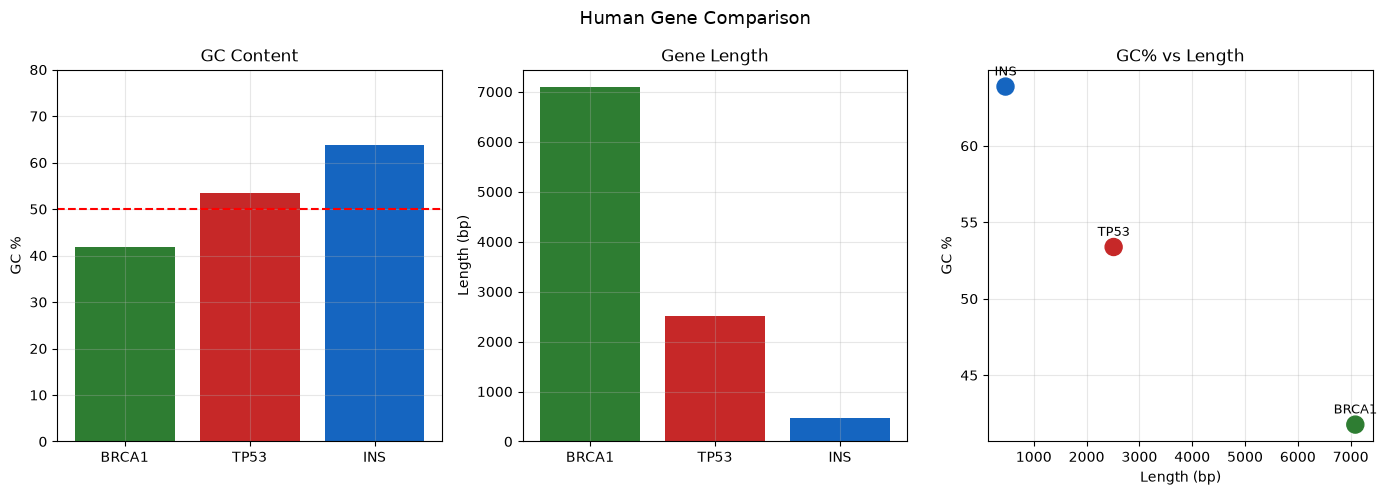

In [4]:
gene_names = list(genes.keys())
colors = ["#2e7d32", "#c62828", "#1565c0"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Human Gene Comparison", fontsize=13)

axes[0].bar(gene_names, [gc_data[g] for g in gene_names], color=colors)
axes[0].axhline(y=50, color="red", linestyle="--")
axes[0].set_title("GC Content")
axes[0].set_ylabel("GC %")
axes[0].set_ylim(0, 80)
axes[0].grid(True, alpha=0.3)

axes[1].bar(gene_names, [lengths[g] for g in gene_names], color=colors)
axes[1].set_title("Gene Length")
axes[1].set_ylabel("Length (bp)")
axes[1].grid(True, alpha=0.3)

gc_vals = [gc_data[g] for g in gene_names]
len_vals = [lengths[g] for g in gene_names]

axes[2].scatter(len_vals, gc_vals, c=colors, s=150, zorder=5)
for i, name in enumerate(gene_names):
    axes[2].annotate(name, (len_vals[i], gc_vals[i]),
                     textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)
axes[2].set_title("GC% vs Length")
axes[2].set_xlabel("Length (bp)")
axes[2].set_ylabel("GC %")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gene_comparison.png", dpi=300)
plt.show()

In [5]:
with open("gene_comparison_report.txt", "w") as f:
    f.write("Gene Comparison Report\n")
    f.write("-" * 30 + "\n\n")

    for name in genes:
        f.write(f"{name}\n")
        f.write(f"  Length : {lengths[name]} bp\n")
        f.write(f"  GC%    : {gc_data[name]:.2f}%\n")
        f.write(f"  DNA    : {str(records[name].seq[:50])}\n\n")

    f.write(f"Most stable: {most_stable} ({gc_data[most_stable]:.1f}%)\n")

print("Report saved.")

Report saved.
